In [5]:
import ROOT
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
from matplotlib import cm
from matplotlib import patches
import mplhep as hep
import os
from tqdm import tqdm
import ipywidgets as widget
import xsec
import itertools

In [6]:
ROOT.gInterpreter.Declare("""
float deepJet_no_sf( float norm, float triggerSF, float pileupWeight, float pileupJetIDWeight, float topPtWeight13TeV, float lepIdSF, float EGammaGsfSF, float isoSF, float L1NonPrefiringProb_CommonCalc, float MCWeight_MultiLepCalc, float btagDeepJetWeight, float btagDeepJet2DWeight_HTnj ){
    return norm * triggerSF * pileupWeight * pileupJetIDWeight * topPtWeight13TeV * lepIdSF * EGammaGsfSF * isoSF * L1NonPrefiringProb_CommonCalc * ( MCWeight_MultiLepCalc / abs( MCWeight_MultiLepCalc ) );
}
""")

ROOT.gInterpreter.Declare("""
float deepJet_sf_only( float norm, float triggerSF, float pileupWeight, float pileupJetIDWeight, float topPtWeight13TeV, float lepIdSF, float EGammaGsfSF, float isoSF, float L1NonPrefiringProb_CommonCalc, float MCWeight_MultiLepCalc, float btagDeepJetWeight, float btagDeepJet2DWeight_HTnj ){
    return norm * triggerSF * pileupWeight * pileupJetIDWeight * topPtWeight13TeV * lepIdSF * EGammaGsfSF * isoSF * L1NonPrefiringProb_CommonCalc * ( MCWeight_MultiLepCalc / abs( MCWeight_MultiLepCalc ) ) * btagDeepJetWeight;
}
""")

ROOT.gInterpreter.Declare("""
float deepJet_renorm( float norm, float triggerSF, float pileupWeight, float pileupJetIDWeight, float topPtWeight13TeV, float lepIdSF, float EGammaGsfSF, float isoSF, float L1NonPrefiringProb_CommonCalc, float MCWeight_MultiLepCalc, float btagDeepJetWeight, float btagDeepJet2DWeight_HTnj ){
    return norm * triggerSF * pileupWeight * pileupJetIDWeight * topPtWeight13TeV * lepIdSF * EGammaGsfSF * isoSF * L1NonPrefiringProb_CommonCalc * ( MCWeight_MultiLepCalc / abs( MCWeight_MultiLepCalc ) ) * btagDeepJetWeight * btagDeepJet2DWeight_HTnj;
}
""")

True

In [7]:
era = "2017"

lumimap = {
    "2016APV": r"$19.52\ fb^{-1}$ (13 TeV)", 
    "2016": r"$16.81\ fb^{-1}$ (13 TeV)",
    "2017": r"$41.48\ fb^{-1}$ (13 TeV)",
    "2018": r"$59.83\ fb^{-1}$ (13 TeV)",
}

postfix = "ttjj" # postfix for save directory
rPath = "root://brux30.hep.brown.edu:1094//store/user/dali/"
#rPath = "root://cmseos.fnal.gov//store/user/dsunyou/"
rDir = rPath + "FWLJMET106XUL_singleLep{}UL_RunIISummer20_3t_step2/nominal/".format( era )
nTree = "ljmet"
fSamples = {
    "ttbb": [
        "TTTo2L2Nu_TuneCP5_13TeV-powheg-pythia8_ttbb_hadd.root",
        "TTToHadronic_TuneCP5_13TeV-powheg-pythia8_ttbb_hadd.root",
        "TTToSemiLepton_HT500Njet9_TuneCP5_13TeV-powheg-pythia8_ttbb_hadd.root",
        "TTToSemiLeptonic_TuneCP5_13TeV-powheg-pythia8_HT0Njet0_ttbb_hadd.root",
        "TTToSemiLeptonic_TuneCP5_13TeV-powheg-pythia8_HT500Njet9_ttbb_hadd.root",
    ],
    "tt1b": [
        "TTTo2L2Nu_TuneCP5_13TeV-powheg-pythia8_tt1b_hadd.root",
        "TTToHadronic_TuneCP5_13TeV-powheg-pythia8_tt1b_hadd.root",
        "TTToSemiLepton_HT500Njet9_TuneCP5_13TeV-powheg-pythia8_tt1b_hadd.root",
        "TTToSemiLeptonic_TuneCP5_13TeV-powheg-pythia8_HT0Njet0_tt1b_hadd.root",
        "TTToSemiLeptonic_TuneCP5_13TeV-powheg-pythia8_HT500Njet9_tt1b_hadd.root",
    ],
    "tt2b": [
        "TTTo2L2Nu_TuneCP5_13TeV-powheg-pythia8_tt2b_hadd.root",
        "TTToHadronic_TuneCP5_13TeV-powheg-pythia8_tt2b_hadd.root",
        "TTToSemiLepton_HT500Njet9_TuneCP5_13TeV-powheg-pythia8_tt2b_hadd.root",
        "TTToSemiLeptonic_TuneCP5_13TeV-powheg-pythia8_HT0Njet0_tt2b_hadd.root",
        "TTToSemiLeptonic_TuneCP5_13TeV-powheg-pythia8_HT500Njet9_tt2b_hadd.root",
    ],
    "ttcc": [
        "TTTo2L2Nu_TuneCP5_13TeV-powheg-pythia8_ttcc_hadd.root",
        "TTToHadronic_TuneCP5_13TeV-powheg-pythia8_ttcc_hadd.root",
        "TTToSemiLepton_HT500Njet9_TuneCP5_13TeV-powheg-pythia8_ttcc_hadd.root",
        "TTToSemiLeptonic_TuneCP5_13TeV-powheg-pythia8_HT0Njet0_ttcc_hadd.root",
        "TTToSemiLeptonic_TuneCP5_13TeV-powheg-pythia8_HT500Njet9_ttcc_hadd.root",
    ],
    "ttjj": [
        "TTTo2L2Nu_TuneCP5_13TeV-powheg-pythia8_ttjj_hadd.root",
        "TTToHadronic_TuneCP5_13TeV-powheg-pythia8_ttjj_hadd.root",
        "TTToSemiLepton_HT500Njet9_TuneCP5_13TeV-powheg-pythia8_tt2b_hadd.root",
        "TTToSemiLeptonic_TuneCP5_13TeV-powheg-pythia8_HT0Njet0_ttjj_1_hadd.root",
        "TTToSemiLeptonic_TuneCP5_13TeV-powheg-pythia8_HT0Njet0_ttjj_2_hadd.root",
        "TTToSemiLeptonic_TuneCP5_13TeV-powheg-pythia8_HT0Njet0_ttjj_3_hadd.root",
        "TTToSemiLeptonic_TuneCP5_13TeV-powheg-pythia8_HT0Njet0_ttjj_4_hadd.root",
        "TTToSemiLeptonic_TuneCP5_13TeV-powheg-pythia8_HT0Njet0_ttjj_5_hadd.root",
        "TTToSemiLeptonic_TuneCP5_13TeV-powheg-pythia8_HT0Njet0_ttjj_6_hadd.root",
        "TTToSemiLeptonic_TuneCP5_13TeV-powheg-pythia8_HT0Njet0_ttjj_7_hadd.root",
        "TTToSemiLeptonic_TuneCP5_13TeV-powheg-pythia8_HT0Njet0_ttjj_8_hadd.root",
        "TTToSemiLeptonic_TuneCP5_13TeV-powheg-pythia8_HT0Njet0_ttjj_9_hadd.root",
        "TTToSemiLeptonic_TuneCP5_13TeV-powheg-pythia8_HT0Njet0_ttjj_10_hadd.root",
        "TTToSemiLeptonic_TuneCP5_13TeV-powheg-pythia8_HT500Njet9_ttjj_hadd.root",
    ]
}

if not os.path.exists( "{}/deepJet_renorm_comparison/{}".format( os.getcwd(), era ) ):
    os.system( "mkdir -vp {}/deepJet_renorm_comparison/{}/".format( os.getcwd(), era ) )

In [8]:
fBase = "DataPastTriggerX == 1 && MCPastTriggerX == 1 && AK4HT > 500 && NJetsCSV_JetSubCalc >= 1 && minDR_lepJet > 0.2"
if era == "2018":
    fBase += " && ( ( isElectron == 1 && ( leptonEta_MultiLepCalc > -1.3 ||  ( leptonPhi_MultiLepCalc < -1.57 || leptonPhi_MultiLepCalc > -0.87 ) ) ) || isMuon == 1 )"
deepJet1D = "btagDeepJetWeight"
deepJet2D = "btagDeepJet2DWeight_HTnj"
variables = [
    "NJets_JetSubCalc",
    "NJetsCSV_JetSubCalc",
    "isElectron",
    "isMuon",
    "AK4HT"
]
rDF = {}
print( "Applying the selection: {}".format( fBase ) )
for f_ in tqdm( fSamples[postfix] ):
    if "HT500" in f_:
        filterStr = fBase + " && isHTgt500Njetge9 == 1"
    else:
        filterStr = fBase
        
    rDF_ = ROOT.RDataFrame( nTree, rDir + f_ ).Filter( fBase + " && isHTgt500Njetge9 == 1" )
    rDF_ = rDF_.Define( "weight_no_deepJet", "deepJet_no_sf( {}, triggerSF, pileupWeight, pileupJetIDWeight, topPtWeight13TeV, lepIdSF, EGammaGsfSF, isoSF, L1NonPrefiringProb_CommonCalc, MCWeight_MultiLepCalc, {}, {} )".format( xsec.norm[f_], deepJet1D, deepJet2D ) )
    rDF_ = rDF_.Define( "weight_no_renorm", "deepJet_sf_only( {},triggerSF, pileupWeight, pileupJetIDWeight, topPtWeight13TeV, lepIdSF, EGammaGsfSF, isoSF, L1NonPrefiringProb_CommonCalc, MCWeight_MultiLepCalc, {}, {} )".format( xsec.norm[f_], deepJet1D, deepJet2D ) )
    rDF_ = rDF_.Define( "weight", "deepJet_renorm( {}, triggerSF, pileupWeight, pileupJetIDWeight, topPtWeight13TeV, lepIdSF, EGammaGsfSF, isoSF, L1NonPrefiringProb_CommonCalc, MCWeight_MultiLepCalc, {}, {} )".format( xsec.norm[f_], deepJet1D, deepJet2D ) )
        
    rDF[f_] = rDF_.AsNumpy( columns = variables + [ "weight", "weight_no_deepJet", "weight_no_renorm" ] )

Applying the selection: DataPastTriggerX == 1 && MCPastTriggerX == 1 && AK4HT > 500 && NJetsCSV_JetSubCalc >= 1 && minDR_lepJet > 0.2


100%|██████████| 14/14 [02:19<00:00, 10.00s/it]


In [11]:
hist = {}
hist_sf_only = {}
hist_no_sf = {}

#variable = "AK4HT"
#bins = np.linspace( 0, 3000, 31 )
variable = "NJets_JetSubCalc"
bins = np.linspace( 3, 14, 12 )

for f_ in fSamples[postfix]:
    hist[f_] = np.histogram( rDF[f_][variable], bins = bins, weights = rDF[f_]["weight"] )
    hist_sf_only[f_] = np.histogram( rDF[f_][variable], bins = bins, weights = rDF[f_]["weight_no_renorm"] )
    hist_no_sf[f_] = np.histogram( rDF[f_][variable], bins = bins, weights = rDF[f_]["weight_no_deepJet"] )
    
total_hist = np.zeros(len(bins)-1)
total_hist_sf_only = np.zeros(len(bins)-1)
total_hist_no_sf = np.zeros(len(bins)-1)

for f_ in fSamples[postfix]:
    total_hist += hist[f_][0]
    total_hist_sf_only += hist_sf_only[f_][0]
    total_hist_no_sf += hist_no_sf[f_][0]

/tmp/ipykernel_450/2282037766.py:25: RuntimeWarning: invalid value encountered in divide
  0.5 * ( bins[1:] + bins[:-1] ), np.nan_to_num( total_hist / total_hist_no_sf ),
/tmp/ipykernel_450/2282037766.py:30: RuntimeWarning: invalid value encountered in divide
  0.5 * ( bins[1:] + bins[:-1] ), np.nan_to_num( total_hist_sf_only / total_hist_no_sf ),


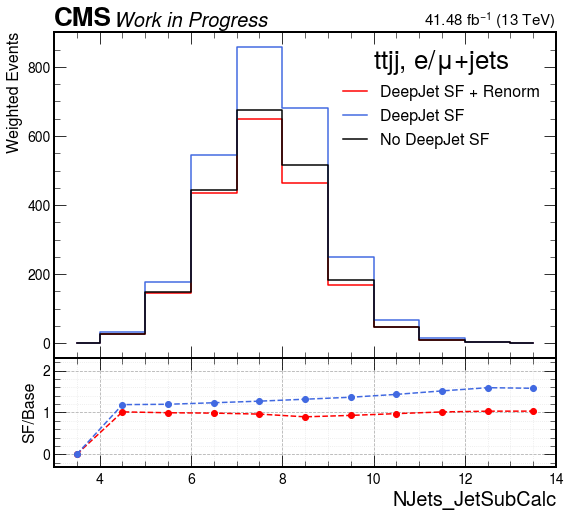

In [12]:
plt.style.use( hep.style.CMS )
fig, subplots = plt.subplots( 2, 1, gridspec_kw = { "height_ratios": [3,1], "hspace": 0 }, figsize = (9,8) )
hep.cms.text( "Work in Progress", fontsize = 20, ax = subplots[0] )
hep.cms.lumitext( lumimap[era], fontsize = 16, ax = subplots[0] )

subplots[0].step( 
    0.5 * ( bins[1:] + bins[:-1] ), total_hist, 
    color = "red", ls = "-", lw = "1.5", where = "mid",
    label = "DeepJet SF + Renorm" 
)

subplots[0].step( 
    0.5 * ( bins[1:] + bins[:-1] ), total_hist_sf_only, 
    color = "royalblue", ls = "-", lw = "1.5", where = "mid",
    label = "DeepJet SF" 
)

subplots[0].step( 
    0.5 * ( bins[1:] + bins[:-1] ), total_hist_no_sf, 
    color = "black", ls = "-", lw = "1.5", where = "mid",
    label = "No DeepJet SF" 
)

subplots[1].plot(
    0.5 * ( bins[1:] + bins[:-1] ), np.nan_to_num( total_hist / total_hist_no_sf ),
    color = "red", ls = "--", lw = 1.5, marker = "o"
)

subplots[1].plot(
    0.5 * ( bins[1:] + bins[:-1] ), np.nan_to_num( total_hist_sf_only / total_hist_no_sf ),
    color = "royalblue", ls = "--", lw = 1.5, marker = "o"
)

subplots[1].set_xlabel( variable, fontsize = 20, ha = "right", x = 1.0 )
subplots[1].set_ylabel( "SF/Base", fontsize = 16, ha = "center", y = 0.5 )
subplots[0].set_ylabel( "Weighted Events", fontsize = 16 )
#subplots[0].set_ylabel( "Weighted Events/{:.0f} GeV".format( bins[1] - bins[0] ), fontsize = 16 )
subplots[0].legend( loc = "best", title = "{}, $e/\mu$+jets".format( postfix ), fontsize = 16 )
subplots[0].set_xticklabels([])
subplots[0].set_xlim( bins[0], bins[-1] )
subplots[0].tick_params( axis = "y", labelsize = 14 )
subplots[1].grid( which = "major", ls = "--", alpha = 1 )
subplots[1].grid( which = "minor", ls = ":", alpha = 0.3 )
subplots[1].tick_params( axis = "x", labelsize = 14 )
subplots[1].set_yticks( [0,1,2], labels = [0,1,2], fontsize = 14 )
subplots[1].set_xlim( bins[0], bins[-1] )
subplots[1].set_ylim( -0.3, 2.3 )
plt.savefig( "{}/deepJet_renorm_comparison/{}/deepJet_renorm_{}_{}_{}.png".format( os.getcwd(), era, era, variable, postfix ) )
plt.show()
plt.close()
